# 05_evaluation_explainability.ipynb

## Purpose
This notebook performs final evaluation and explainability for your **non-fusion** DementiaBank Pitt Cookie Theft research.

It compares the two separate models you trained earlier:

```text
1. Transcript-only model from 02_train_transcript_model.ipynb
2. Audio-only model from 04_train_audio_model.ipynb
```

This notebook does **not** combine/fuse transcript and audio features. It evaluates them separately and prepares final report/dashboard-ready outputs.

It will:
- Load trained transcript and audio models
- Load transcript and audio test predictions
- Compare model performance
- Create final comparison charts
- Extract transcript feature explanations
- Extract audio feature importance explanations
- Generate sample JSON outputs
- Save final summary files for report writing

Final research framing:

```text
This is a research-based dementia risk screening system.
It is not a clinical diagnosis system.
```

## 1. Import required libraries

In [1]:
from pathlib import Path
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 150)

RANDOM_STATE = 42
CLASS_NAMES = ["Control", "Dementia"]

## 2. Set paths

In [2]:
MODEL_DIR = Path("models")
REPORT_DIR = Path("reports")
PROCESSED_DIR = Path("data/processed")
SPLIT_DIR = Path("data/splits")

REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Model files
TEXT_MODEL_PATH = MODEL_DIR / "text_dementia_model.joblib"
AUDIO_MODEL_PATH = MODEL_DIR / "audio_dementia_model.joblib"
AUDIO_FEATURE_COLUMNS_PATH = MODEL_DIR / "audio_feature_columns.json"

# Prediction/report files created by previous notebooks
TEXT_PREDICTIONS_PATH = REPORT_DIR / "text_test_predictions.csv"
AUDIO_PREDICTIONS_PATH = REPORT_DIR / "audio_test_predictions.csv"

TEXT_METADATA_PATH = REPORT_DIR / "text_model_metadata.json"
AUDIO_METADATA_PATH = REPORT_DIR / "audio_model_metadata.json"

# Raw processed datasets/splits
TRANSCRIPTS_DATASET_PATH = PROCESSED_DIR / "transcripts_dataset.csv"
AUDIO_FEATURES_DATASET_PATH = PROCESSED_DIR / "audio_features_dataset.csv"
TEXT_TEST_PATH = SPLIT_DIR / "test.csv"
AUDIO_TEST_PATH = SPLIT_DIR / "audio_test.csv"

paths = {
    "Text model": TEXT_MODEL_PATH,
    "Audio model": AUDIO_MODEL_PATH,
    "Audio feature columns": AUDIO_FEATURE_COLUMNS_PATH,
    "Text predictions": TEXT_PREDICTIONS_PATH,
    "Audio predictions": AUDIO_PREDICTIONS_PATH,
    "Text metadata": TEXT_METADATA_PATH,
    "Audio metadata": AUDIO_METADATA_PATH,
    "Transcript dataset": TRANSCRIPTS_DATASET_PATH,
    "Audio features dataset": AUDIO_FEATURES_DATASET_PATH,
}

for name, path in paths.items():
    print(f"{name}: {path.exists()} -> {path}")

Text model: True -> models\text_dementia_model.joblib
Audio model: True -> models\audio_dementia_model.joblib
Audio feature columns: True -> models\audio_feature_columns.json
Text predictions: True -> reports\text_test_predictions.csv
Audio predictions: True -> reports\audio_test_predictions.csv
Text metadata: True -> reports\text_model_metadata.json
Audio metadata: True -> reports\audio_model_metadata.json
Transcript dataset: True -> data\processed\transcripts_dataset.csv
Audio features dataset: True -> data\processed\audio_features_dataset.csv


## 3. Load models and metadata

If a file is missing, run the previous notebooks first:

```text
01_parse_cha_files.ipynb
02_train_transcript_model.ipynb
03_extract_audio_features.ipynb
04_train_audio_model.ipynb
```

In [17]:
def load_json_if_exists(path: Path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return None


# Custom classes required to unpickle the transcript model pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import issparse
import re


def extract_runtime_ling_features(texts):
    rows = []
    for text in texts:
        text = str(text)
        words = text.split()
        word_count = len(words)
        unique_words = len(set(words))
        ttr = unique_words / word_count if word_count > 0 else 0

        avg_word_len = np.mean([len(w) for w in words]) if words else 0
        long_word_ratio = sum(1 for w in words if len(w) > 6) / word_count if word_count > 0 else 0

        sentences = [s.strip() for s in re.split(r"[.!?]+", text) if s.strip()]
        num_sentences = len(sentences)
        avg_sent_len = word_count / num_sentences if num_sentences > 0 else word_count

        word_pairs = list(zip(words, words[1:]))
        consecutive_repeats = sum(1 for a, b in word_pairs if a.lower() == b.lower())

        dementia_words = ['um', 'uh', 'well', 'you know', 'i mean', 'like', 'yeah', 'right']
        filler_count_rt = sum(text.lower().count(w) for w in dementia_words)

        content_words = ['cookie', 'woman', 'boy', 'girl', 'stool', 'sink', 'water',
                         'window', 'kitchen', 'dishes', 'mother', 'overflow', 'cabinet']
        content_hit = sum(1 for w in content_words if w in text.lower())

        rows.append([
            word_count, unique_words, ttr, avg_word_len, long_word_ratio,
            num_sentences, avg_sent_len, consecutive_repeats,
            filler_count_rt, content_hit
        ])

    return np.array(rows, dtype=float)


class RuntimeLingTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        arr = extract_runtime_ling_features(X)
        return np.clip(arr, 0, np.percentile(arr, 99, axis=0) + 1e-8)


class DenseTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if issparse(X):
            return X.toarray()
        return np.array(X)


text_model = joblib.load(TEXT_MODEL_PATH) if TEXT_MODEL_PATH.exists() else None
audio_model = joblib.load(AUDIO_MODEL_PATH) if AUDIO_MODEL_PATH.exists() else None

text_metadata = load_json_if_exists(TEXT_METADATA_PATH)
audio_metadata = load_json_if_exists(AUDIO_METADATA_PATH)

audio_feature_columns = load_json_if_exists(AUDIO_FEATURE_COLUMNS_PATH)

print("Text model loaded:", text_model is not None)
print("Audio model loaded:", audio_model is not None)

if text_metadata:
    print("\nText model name:", text_metadata.get("model_name"))
if audio_metadata:
    print("Audio model name:", audio_metadata.get("model_name"))


Text model loaded: True
Audio model loaded: True

Text model name: LR_Combined
Audio model name: Audio_LogisticRegression


## 4. Load test prediction files

In [18]:
text_pred_df = pd.read_csv(TEXT_PREDICTIONS_PATH) if TEXT_PREDICTIONS_PATH.exists() else None
audio_pred_df = pd.read_csv(AUDIO_PREDICTIONS_PATH) if AUDIO_PREDICTIONS_PATH.exists() else None

if text_pred_df is not None:
    print("Text predictions shape:", text_pred_df.shape)
    display(text_pred_df.head())
else:
    print("Text prediction file not found. Run 02_train_transcript_model.ipynb first.")

if audio_pred_df is not None:
    print("\nAudio predictions shape:", audio_pred_df.shape)
    display(audio_pred_df.head())
else:
    print("Audio prediction file not found. Run 04_train_audio_model.ipynb first.")

Text predictions shape: (83, 7)


,file_id,label,predicted_label,prob_control,prob_dementia,correct,transcript
0,035-1,Dementia,Dementia,0.283232,0.716768,True,alright the little girl s wants cookie 5336 8300 the boy is getting her one but the s stool is going to he's going to fall off the stool 9612 1556...
1,021-4,Control,Dementia,0.105307,0.894693,False,alright a little girl is reaching for the cookie cookie that the boy's reaching for the cookie to give to her while the the stool is being tipped ...
2,021-3,Control,Control,0.719595,0.280405,True,alright 2980 3230 mother's doing the dishes 3700 4901 the sink is overflowing 4975 6141 the stool is falling 7022 9464 the boy is going for the co...
3,010-1,Dementia,Control,0.824968,0.175032,False,oh boy alright 3959 4199 family is in the kitchen 5360 6950 the mother's washing dishes 7856 9526 and her sink is overflowing 10763 11753 and she'...
4,292-1,Control,Control,0.503364,0.496636,True,girl is reaching up 3433 4553 the boy is is taking cookies out of the cookie jar 4622 9718 the stool is tilting 10145 12681 mother is washing the ...



Audio predictions shape: (83, 6)


,file_id,label,predicted_label,prob_control,prob_dementia,correct
0,035-1,Dementia,Dementia,0.037971,0.962029,True
1,021-4,Control,Control,0.983521,0.016479,True
2,021-3,Control,Control,0.995514,0.004486,True
3,010-1,Dementia,Dementia,0.020137,0.979863,True
4,292-1,Control,Control,0.974554,0.025446,True


## 5. Evaluation helper functions

In [19]:
def label_to_id(series):
    return series.map({"Control": 0, "Dementia": 1}).astype(int)


def compute_metrics_from_prediction_df(df: pd.DataFrame, model_type: str):
    required_cols = ["label", "predicted_label", "prob_dementia"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"{model_type} prediction file missing columns: {missing}")

    y_true = label_to_id(df["label"])
    y_pred = label_to_id(df["predicted_label"])
    y_prob = df["prob_dementia"].astype(float)

    # Some prediction files may store probabilities as 0-1. If >1, assume percentage and convert to 0-1.
    if y_prob.max() > 1:
        y_prob = y_prob / 100.0

    metrics = {
        "model_type": model_type,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_dementia": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_dementia": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_dementia": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "auc_roc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan,
        "num_test_samples": len(df),
        "num_correct": int((y_true == y_pred).sum()),
        "num_wrong": int((y_true != y_pred).sum()),
    }

    return metrics, y_true, y_pred, y_prob


def risk_level_from_probability(dementia_prob_percent: float) -> str:
    if dementia_prob_percent >= 70:
        return "High"
    elif dementia_prob_percent >= 40:
        return "Medium"
    else:
        return "Low"

## 6. Final performance comparison

In [20]:
comparison_rows = []
evaluation_objects = {}

if text_pred_df is not None:
    text_metrics, text_y_true, text_y_pred, text_y_prob = compute_metrics_from_prediction_df(text_pred_df, "Transcript-only")
    comparison_rows.append(text_metrics)
    evaluation_objects["Transcript-only"] = (text_y_true, text_y_pred, text_y_prob)

if audio_pred_df is not None:
    audio_metrics, audio_y_true, audio_y_pred, audio_y_prob = compute_metrics_from_prediction_df(audio_pred_df, "Audio-only")
    comparison_rows.append(audio_metrics)
    evaluation_objects["Audio-only"] = (audio_y_true, audio_y_pred, audio_y_prob)

if not comparison_rows:
    raise ValueError("No prediction files found. Run notebooks 02 and 04 first.")

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df[[
    "model_type", "accuracy", "precision_dementia", "recall_dementia",
    "f1_dementia", "f1_weighted", "auc_roc", "num_test_samples", "num_correct", "num_wrong"
]]

display(comparison_df)

comparison_path = REPORT_DIR / "final_model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path.resolve())

,model_type,accuracy,precision_dementia,recall_dementia,f1_dementia,f1_weighted,auc_roc,num_test_samples,num_correct,num_wrong
0,Transcript-only,0.698795,0.8,0.608696,0.691358,0.697833,0.766745,83,58,25
1,Audio-only,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,83,83,0


Saved: C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\final_model_comparison.csv


## 7. Plot model comparison chart

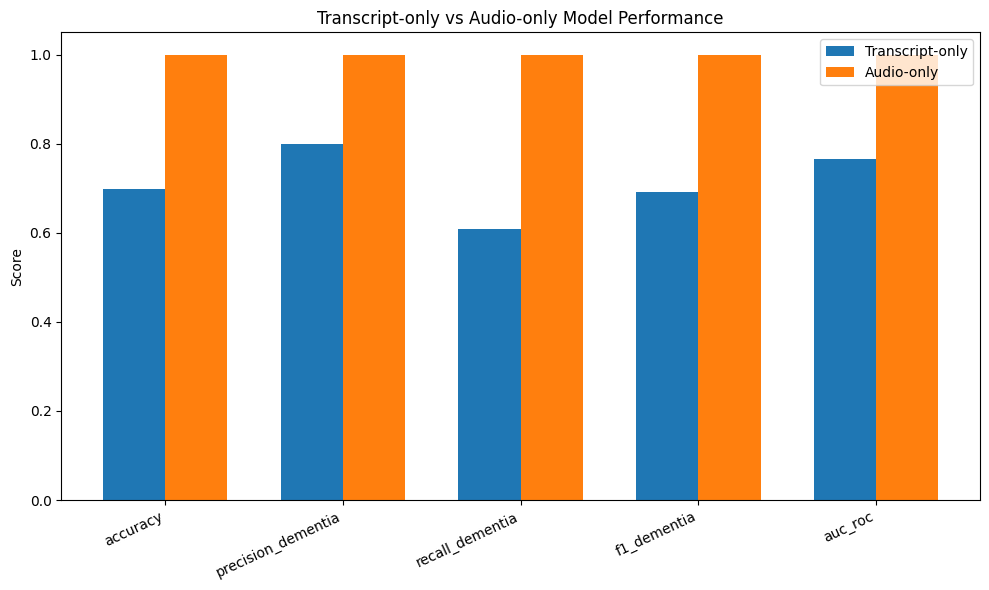

Saved: C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\final_model_comparison_chart.png


In [21]:
metric_cols = ["accuracy", "precision_dementia", "recall_dementia", "f1_dementia", "auc_roc"]

plot_df = comparison_df.set_index("model_type")[metric_cols]

plt.figure(figsize=(10, 6))
x = np.arange(len(metric_cols))
width = 0.35 if len(plot_df) > 1 else 0.5

for i, (model_name, row) in enumerate(plot_df.iterrows()):
    offset = (i - (len(plot_df) - 1) / 2) * width
    plt.bar(x + offset, row.values, width=width, label=model_name)

plt.xticks(x, metric_cols, rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Transcript-only vs Audio-only Model Performance")
plt.legend()
plt.tight_layout()

comparison_chart_path = REPORT_DIR / "final_model_comparison_chart.png"
plt.savefig(comparison_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", comparison_chart_path.resolve())

## 8. Confusion matrices for final report

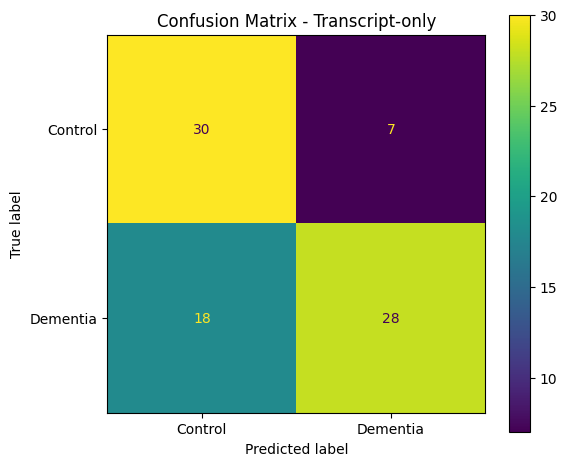

Saved: C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\final_confusion_matrix_transcript_only.png
              precision    recall  f1-score   support

     Control       0.62      0.81      0.71        37
    Dementia       0.80      0.61      0.69        46

    accuracy                           0.70        83
   macro avg       0.71      0.71      0.70        83
weighted avg       0.72      0.70      0.70        83



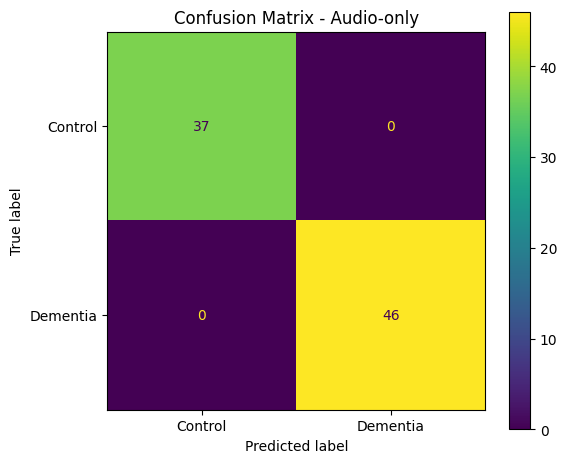

Saved: C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\final_confusion_matrix_audio_only.png
              precision    recall  f1-score   support

     Control       1.00      1.00      1.00        37
    Dementia       1.00      1.00      1.00        46

    accuracy                           1.00        83
   macro avg       1.00      1.00      1.00        83
weighted avg       1.00      1.00      1.00        83



In [22]:
for model_name, (y_true, y_pred, y_prob) in evaluation_objects.items():
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()

    out_path = REPORT_DIR / f"final_confusion_matrix_{model_name.lower().replace('-', '_')}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path.resolve())
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

## 9. ROC curves for final report

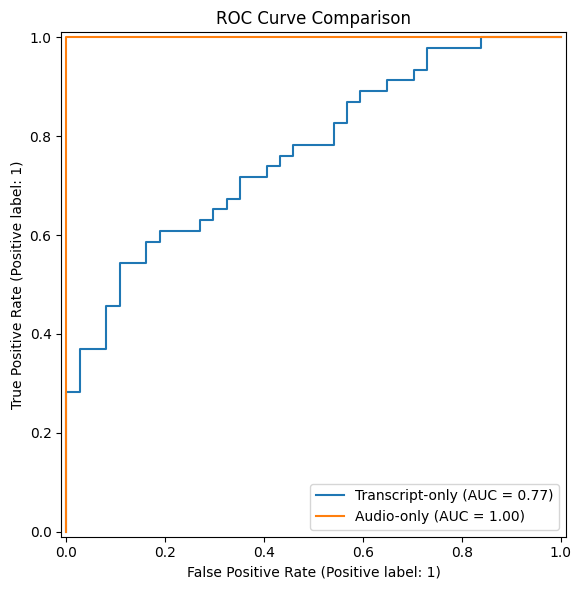

Saved: C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\final_roc_curve_comparison.png


In [10]:
plt.figure(figsize=(7, 6))
ax = plt.gca()

for model_name, (y_true, y_pred, y_prob) in evaluation_objects.items():
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax, name=model_name)

plt.title("ROC Curve Comparison")
plt.tight_layout()
roc_compare_path = REPORT_DIR / "final_roc_curve_comparison.png"
plt.savefig(roc_compare_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", roc_compare_path.resolve())

## 10. Precision-Recall curves for final report

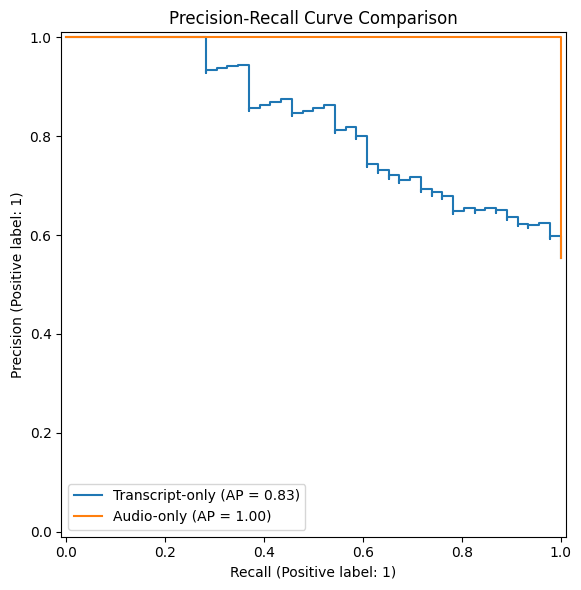

Saved: C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\final_precision_recall_curve_comparison.png


In [11]:
plt.figure(figsize=(7, 6))
ax = plt.gca()

for model_name, (y_true, y_pred, y_prob) in evaluation_objects.items():
    PrecisionRecallDisplay.from_predictions(y_true, y_prob, ax=ax, name=model_name)

plt.title("Precision-Recall Curve Comparison")
plt.tight_layout()
pr_compare_path = REPORT_DIR / "final_precision_recall_curve_comparison.png"
plt.savefig(pr_compare_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pr_compare_path.resolve())

## 11. Transcript model explainability

For TF-IDF + linear models, this section shows the words/phrases that most strongly support each class.

Interpret carefully:
- These are statistical model features, not clinical proof.
- They help explain what the model learned from the training data.
- Do not claim these features diagnose dementia.

In [12]:
def extract_text_model_explanations(model, top_n=25):
    if model is None:
        print("Text model not loaded.")
        return None, None

    if not hasattr(model, "named_steps") or "tfidf" not in model.named_steps:
        print("Text model is not a TF-IDF pipeline.")
        return None, None

    vectorizer = model.named_steps["tfidf"]
    classifier = model.named_steps["classifier"]
    feature_names = np.array(vectorizer.get_feature_names_out())

    coefs = None

    # Logistic Regression style
    if hasattr(classifier, "coef_"):
        coefs = classifier.coef_[0]

    # Calibrated LinearSVC style
    elif hasattr(classifier, "calibrated_classifiers_"):
        try:
            base_estimator = classifier.calibrated_classifiers_[0].estimator
            if hasattr(base_estimator, "coef_"):
                coefs = base_estimator.coef_[0]
        except Exception as e:
            print("Could not extract calibrated SVM coefficients:", e)

    if coefs is None:
        print("Coefficient-based explanation is not available for this text classifier.")
        return None, None

    dementia_idx = np.argsort(coefs)[-top_n:][::-1]
    control_idx = np.argsort(coefs)[:top_n]

    dementia_df = pd.DataFrame({
        "rank": range(1, top_n + 1),
        "feature": feature_names[dementia_idx],
        "weight": coefs[dementia_idx],
        "supports_class": "Dementia"
    })

    control_df = pd.DataFrame({
        "rank": range(1, top_n + 1),
        "feature": feature_names[control_idx],
        "weight": coefs[control_idx],
        "supports_class": "Control"
    })

    return dementia_df, control_df


text_dementia_features, text_control_features = extract_text_model_explanations(text_model, top_n=25)

if text_dementia_features is not None:
    print("Top transcript features supporting Dementia class:")
    display(text_dementia_features)

    print("Top transcript features supporting Control class:")
    display(text_control_features)

    text_dementia_features.to_csv(REPORT_DIR / "final_text_features_supporting_dementia.csv", index=False)
    text_control_features.to_csv(REPORT_DIR / "final_text_features_supporting_control.csv", index=False)

Text model is not a TF-IDF pipeline.


## 12. Plot transcript feature explanations

In [13]:
if text_dementia_features is not None:
    top_plot = text_dementia_features.head(15)
    plt.figure(figsize=(8, 6))
    plt.barh(top_plot["feature"][::-1], top_plot["weight"][::-1])
    plt.xlabel("Model Weight")
    plt.title("Top Transcript Features Supporting Dementia Class")
    plt.tight_layout()
    out_path = REPORT_DIR / "final_text_features_dementia.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path.resolve())

    top_plot = text_control_features.head(15)
    plt.figure(figsize=(8, 6))
    plt.barh(top_plot["feature"][::-1], top_plot["weight"][::-1])
    plt.xlabel("Model Weight")
    plt.title("Top Transcript Features Supporting Control Class")
    plt.tight_layout()
    out_path = REPORT_DIR / "final_text_features_control.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path.resolve())
else:
    print("Skipping transcript feature plot because coefficient explanation is not available.")

Skipping transcript feature plot because coefficient explanation is not available.


## 13. Audio model explainability

This section extracts feature importance for tree models or coefficient importance for linear models.

Common useful audio indicators:
- Pause ratio
- Speech ratio
- MFCC features
- Energy/RMS
- Pitch/F0
- Spectral centroid/bandwidth/rolloff

In [14]:
def get_feature_names_after_audio_pipeline(model, original_feature_cols):
    feature_names = np.array(original_feature_cols)

    if model is None or not hasattr(model, "named_steps"):
        return feature_names

    if "variance" in model.named_steps:
        mask = model.named_steps["variance"].get_support()
        feature_names = feature_names[mask]

    if "feature_selection" in model.named_steps:
        mask = model.named_steps["feature_selection"].get_support()
        feature_names = feature_names[mask]

    return feature_names


def extract_audio_model_explanations(model, original_feature_cols, top_n=30):
    if model is None:
        print("Audio model not loaded.")
        return None

    if not hasattr(model, "named_steps") or "classifier" not in model.named_steps:
        print("Audio model is not a supported sklearn pipeline.")
        return None

    classifier = model.named_steps["classifier"]
    feature_names = get_feature_names_after_audio_pipeline(model, original_feature_cols)

    importance_values = None
    importance_type = None

    if hasattr(classifier, "feature_importances_"):
        importance_values = classifier.feature_importances_
        importance_type = "tree_feature_importance"
    elif hasattr(classifier, "coef_"):
        importance_values = np.abs(classifier.coef_[0])
        importance_type = "absolute_coefficient"

    if importance_values is None:
        print("Direct feature importance is not available for this audio classifier.")
        return None

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance_values,
        "importance_type": importance_type
    }).sort_values("importance", ascending=False).head(top_n)

    importance_df.insert(0, "rank", range(1, len(importance_df) + 1))
    return importance_df


audio_importance_df = None
if audio_feature_columns is not None:
    audio_importance_df = extract_audio_model_explanations(audio_model, audio_feature_columns, top_n=30)

if audio_importance_df is not None:
    display(audio_importance_df)
    audio_importance_df.to_csv(REPORT_DIR / "final_audio_feature_importance.csv", index=False)
else:
    print("Audio feature importance could not be extracted. This is normal for some model types such as RBF SVM.")

Audio model is not a supported sklearn pipeline.
Audio feature importance could not be extracted. This is normal for some model types such as RBF SVM.


## 14. Plot audio feature importance

In [15]:
if audio_importance_df is not None:
    top_plot = audio_importance_df.head(20)
    plt.figure(figsize=(9, 8))
    plt.barh(top_plot["feature"][::-1], top_plot["importance"][::-1])
    plt.xlabel("Importance")
    plt.title("Top Audio Feature Importance")
    plt.tight_layout()
    out_path = REPORT_DIR / "final_audio_feature_importance.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path.resolve())
else:
    print("Skipping audio feature importance plot.")

Skipping audio feature importance plot.


## 15. Error analysis

This section lists wrong predictions for both models.

Use this in your discussion chapter to explain limitations.

In [23]:
if text_pred_df is not None:
    text_errors = text_pred_df[text_pred_df['correct'] == False].copy()
    print('Transcript model wrong predictions:', len(text_errors))
    text_cols = [c for c in ['file_id', 'label', 'predicted_label', 'prob_control', 'prob_dementia', 'transcript'] if c in text_errors.columns]
    display(text_errors[text_cols].head(20))
    text_errors.to_csv(REPORT_DIR / 'final_text_error_analysis.csv', index=False)

if audio_pred_df is not None:
    audio_errors = audio_pred_df[audio_pred_df['correct'] == False].copy()
    print('\nAudio model wrong predictions:', len(audio_errors))
    audio_cols = [c for c in ['file_id', 'label', 'predicted_label', 'prob_control', 'prob_dementia', 'audio_path'] if c in audio_errors.columns]
    display(audio_errors[audio_cols].head(20))
    audio_errors.to_csv(REPORT_DIR / 'final_audio_error_analysis.csv', index=False)


Transcript model wrong predictions: 25


,file_id,label,predicted_label,prob_control,prob_dementia,transcript
1,021-4,Control,Dementia,0.105307,0.894693,alright a little girl is reaching for the cookie cookie that the boy's reaching for the cookie to give to her while the the stool is being tipped ...
3,010-1,Dementia,Control,0.824968,0.175032,oh boy alright 3959 4199 family is in the kitchen 5360 6950 the mother's washing dishes 7856 9526 and her sink is overflowing 10763 11753 and she'...
6,016-4,Dementia,Control,0.871743,0.128257,well the little girl wants the cookie that the guy's steal k kid is stealing from the cookie jar with the lid off 7856 14202 and he's tipping off ...
8,057-0,Dementia,Control,0.624300,0.375700,okay i see a boy on a stool 5565 9509 and the stool is falling over while he is reaching for the cookie jar 9840 15846 and his sister is reaching ...
10,221-3,Dementia,Control,0.729367,0.270633,well the boy is taking cookies out of the cookie jar 1812 6001 and he's handing one to his sister as he almost falls off his stool 6380 13674 and ...
14,021-0,Control,Dementia,0.460049,0.539951,further right 780 1510 oh tha there's a little girl reaching 2020 3861 oh let's say the little boy's reaching for the cookie in the jar 4982 7725 ...
18,043-0,Dementia,Control,0.771858,0.228142,there's a little girl 5095 5493 and a little boy standing on top of a stool 8499 10842 and it looks like a mother maybe washing the dishes in the ...
22,242-0,Control,Dementia,0.194175,0.805825,well the stool is tilting as the kid is taking cookies to give to his sister 3600 8010 the water's running over in the sink 20091 21451 the mother...
23,663-0,Dementia,Control,0.571756,0.428244,well the boy on the stool is falling reaching up for a cookie handing one to the girl 920 7490 the lady is wiping a dish 7725 10280 water running ...
24,334-1,Dementia,Control,0.568358,0.431642,well the boy is reaching for s some cookies 12616 15757 and they're in a jar in a cupboard 16438 17653 and the stool is breaking down 17739 19370 ...



Audio model wrong predictions: 0


,file_id,label,predicted_label,prob_control,prob_dementia


## 16. Agreement analysis between transcript-only and audio-only models

This is **not fusion**. It only compares whether the two separate models agree on shared test files.

In [24]:
agreement_df = None

if text_pred_df is not None and audio_pred_df is not None:
    text_small = text_pred_df[["file_id", "label", "predicted_label", "prob_dementia", "correct"]].rename(columns={
        "predicted_label": "text_predicted_label",
        "prob_dementia": "text_prob_dementia",
        "correct": "text_correct"
    })

    audio_small = audio_pred_df[["file_id", "label", "predicted_label", "prob_dementia", "correct"]].rename(columns={
        "predicted_label": "audio_predicted_label",
        "prob_dementia": "audio_prob_dementia",
        "correct": "audio_correct"
    })

    agreement_df = pd.merge(text_small, audio_small, on=["file_id", "label"], how="inner")
    agreement_df["models_agree"] = agreement_df["text_predicted_label"] == agreement_df["audio_predicted_label"]

    print("Shared test files:", len(agreement_df))
    if len(agreement_df) > 0:
        print("Model agreement rate:", round(agreement_df["models_agree"].mean(), 4))
        display(agreement_df.head(20))

        agreement_path = REPORT_DIR / "final_text_audio_agreement_analysis.csv"
        agreement_df.to_csv(agreement_path, index=False)
        print("Saved:", agreement_path.resolve())
else:
    print("Both text and audio prediction files are required for agreement analysis.")

Shared test files: 83
Model agreement rate: 0.6988


,file_id,label,text_predicted_label,text_prob_dementia,text_correct,audio_predicted_label,audio_prob_dementia,audio_correct,models_agree
0,035-1,Dementia,Dementia,0.716768,True,Dementia,0.962029,True,True
1,021-4,Control,Dementia,0.894693,False,Control,0.016479,True,False
2,021-3,Control,Control,0.280405,True,Control,0.004486,True,True
3,010-1,Dementia,Control,0.175032,False,Dementia,0.979863,True,False
4,292-1,Control,Control,0.496636,True,Control,0.025446,True,True
5,274-2,Control,Control,0.314427,True,Control,0.040878,True,True
6,016-4,Dementia,Control,0.128257,False,Dementia,0.938075,True,False
7,470-1,Dementia,Dementia,0.903833,True,Dementia,0.984177,True,True
8,057-0,Dementia,Control,0.375700,False,Dementia,0.972809,True,False
9,071-2,Control,Control,0.092184,True,Control,0.024504,True,True


Saved: C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\final_text_audio_agreement_analysis.csv


## 17. Sample final JSON outputs

These outputs are suitable for a dashboard or API response.

They clearly state that this is not a clinical diagnosis.

In [25]:
def make_prediction_json(row, model_type="Transcript-only"):
    prob_control = float(row["prob_control"])
    prob_dementia = float(row["prob_dementia"])

    # Convert to percentages if stored as 0-1
    if prob_control <= 1 and prob_dementia <= 1:
        prob_control *= 100
        prob_dementia *= 100

    predicted_class = row["predicted_label"]
    confidence = max(prob_control, prob_dementia)

    if model_type == "Transcript-only":
        input_type = "CHAT transcript participant speech"
        indicators = {
            "explanation_type": "TF-IDF word/phrase influence",
            "possible_language_markers": [
                "lexical diversity",
                "word usage patterns",
                "description completeness",
                "repetition and hesitation markers"
            ]
        }
    else:
        input_type = "audio-derived acoustic features"
        indicators = {
            "explanation_type": "audio feature importance",
            "possible_acoustic_markers": [
                "pause ratio",
                "speech ratio",
                "MFCC patterns",
                "energy",
                "pitch",
                "spectral features"
            ]
        }

    return {
        "input_metadata": {
            "file_id": str(row.get("file_id", "unknown")),
            "model_type": model_type,
            "input_type": input_type,
            "task": "Cookie Theft picture description",
            "dataset": "DementiaBank Pitt Corpus"
        },
        "prediction": {
            "predicted_class": predicted_class,
            "risk_level": risk_level_from_probability(prob_dementia),
            "confidence": round(confidence, 2),
            "probabilities": {
                "Control": round(prob_control, 2),
                "Dementia": round(prob_dementia, 2)
            }
        },
        "explainability": indicators,
        "clinical_note": "This output is for research-based dementia risk screening only. It is not a clinical diagnosis."
    }


sample_outputs = []

if text_pred_df is not None and len(text_pred_df) > 0:
    sample_text_row = text_pred_df.sample(1, random_state=RANDOM_STATE).iloc[0]
    sample_outputs.append(make_prediction_json(sample_text_row, "Transcript-only"))

if audio_pred_df is not None and len(audio_pred_df) > 0:
    sample_audio_row = audio_pred_df.sample(1, random_state=RANDOM_STATE).iloc[0]
    sample_outputs.append(make_prediction_json(sample_audio_row, "Audio-only"))

sample_json_path = REPORT_DIR / "final_sample_prediction_outputs.json"
with open(sample_json_path, "w", encoding="utf-8") as f:
    json.dump(sample_outputs, f, indent=2)

print(json.dumps(sample_outputs, indent=2))
print("Saved:", sample_json_path.resolve())

[
  {
    "input_metadata": {
      "file_id": "183-3",
      "model_type": "Transcript-only",
      "input_type": "CHAT transcript participant speech",
      "task": "Cookie Theft picture description",
      "dataset": "DementiaBank Pitt Corpus"
    },
    "prediction": {
      "predicted_class": "Control",
      "risk_level": "Low",
      "confidence": 68.78,
      "probabilities": {
        "Control": 68.78,
        "Dementia": 31.22
      }
    },
    "explainability": {
      "explanation_type": "TF-IDF word/phrase influence",
      "possible_language_markers": [
        "lexical diversity",
        "word usage patterns",
        "description completeness",
        "repetition and hesitation markers"
      ]
    },
    "clinical_note": "This output is for research-based dementia risk screening only. It is not a clinical diagnosis."
  },
  {
    "input_metadata": {
      "file_id": "183-3",
      "model_type": "Audio-only",
      "input_type": "audio-derived acoustic features",
   

## 18. Create final evaluation summary JSON

In [26]:
best_row = comparison_df.sort_values(by=["f1_dementia", "recall_dementia", "auc_roc"], ascending=False).iloc[0]

final_summary = {
    "research_title": "Speech-Based Dementia Risk Detection Using the DementiaBank Pitt Cookie Theft Dataset",
    "research_scope": "Non-fusion evaluation of transcript-only and audio-only models.",
    "dataset": "DementiaBank Pitt Cookie Theft Corpus",
    "classes": {
        "0": "Control",
        "1": "Dementia"
    },
    "models_evaluated": comparison_df.to_dict(orient="records"),
    "best_model_by_validation_style_ranking": {
        "model_type": best_row["model_type"],
        "accuracy": float(best_row["accuracy"]),
        "precision_dementia": float(best_row["precision_dementia"]),
        "recall_dementia": float(best_row["recall_dementia"]),
        "f1_dementia": float(best_row["f1_dementia"]),
        "auc_roc": float(best_row["auc_roc"]),
    },
    "important_interpretation_note": "The best model is selected based on screening-oriented metrics such as dementia recall, F1-score, and AUC-ROC, not accuracy alone.",
    "clinical_note": "This system is for research-based dementia risk screening only and is not a clinical diagnosis."
}

summary_path = REPORT_DIR / "final_evaluation_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=2)

print(json.dumps(final_summary, indent=2))
print("Saved:", summary_path.resolve())

{
  "research_title": "Speech-Based Dementia Risk Detection Using the DementiaBank Pitt Cookie Theft Dataset",
  "research_scope": "Non-fusion evaluation of transcript-only and audio-only models.",
  "dataset": "DementiaBank Pitt Cookie Theft Corpus",
  "classes": {
    "0": "Control",
    "1": "Dementia"
  },
  "models_evaluated": [
    {
      "model_type": "Transcript-only",
      "accuracy": 0.6987951807228916,
      "precision_dementia": 0.8,
      "recall_dementia": 0.6086956521739131,
      "f1_dementia": 0.691358024691358,
      "f1_weighted": 0.6978327252364579,
      "auc_roc": 0.7667450058754407,
      "num_test_samples": 83,
      "num_correct": 58,
      "num_wrong": 25
    },
    {
      "model_type": "Audio-only",
      "accuracy": 1.0,
      "precision_dementia": 1.0,
      "recall_dementia": 1.0,
      "f1_dementia": 1.0,
      "f1_weighted": 1.0,
      "auc_roc": 1.0,
      "num_test_samples": 83,
      "num_correct": 83,
      "num_wrong": 0
    }
  ],
  "best_model_

## 19. Generate final report text file

In [27]:
report_text = f"""
FINAL EVALUATION AND EXPLAINABILITY SUMMARY
============================================

Research Title:
Speech-Based Dementia Risk Detection Using the DementiaBank Pitt Cookie Theft Dataset

Research Scope:
This research evaluates transcript-only and audio-only dementia classification models separately.
No multimodal fusion is performed in this phase.

Dataset:
DementiaBank Pitt Cookie Theft Corpus

Classes:
0 = Control
1 = Dementia

Model Comparison:
{comparison_df.to_string(index=False)}

Best Model Based on F1, Recall, and AUC:
{best_row['model_type']}

Interpretation:
Accuracy alone is not sufficient for this screening-style task. Dementia-class recall,
Dementia F1-score, and AUC-ROC should be considered because the model should avoid
missing possible dementia-pattern samples.

Explainability:
The transcript model is explained using TF-IDF feature influence or model coefficients.
The audio model is explained using feature importance or coefficient magnitude where available.
These explanations are statistical model explanations and must not be interpreted as clinical proof.

Clinical/Research Disclaimer:
This output is for research-based dementia risk screening only. It is not a clinical diagnosis.
A clinician must make any medical interpretation or diagnosis.
"""

final_report_path = REPORT_DIR / "final_evaluation_explainability_report.txt"
with open(final_report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)
print("Saved:", final_report_path.resolve())


FINAL EVALUATION AND EXPLAINABILITY SUMMARY

Research Title:
Speech-Based Dementia Risk Detection Using the DementiaBank Pitt Cookie Theft Dataset

Research Scope:
This research evaluates transcript-only and audio-only dementia classification models separately.
No multimodal fusion is performed in this phase.

Dataset:
DementiaBank Pitt Cookie Theft Corpus

Classes:
0 = Control
1 = Dementia

Model Comparison:
     model_type  accuracy  precision_dementia  recall_dementia  f1_dementia  f1_weighted  auc_roc  num_test_samples  num_correct  num_wrong
Transcript-only  0.698795                 0.8         0.608696     0.691358     0.697833 0.766745                83           58         25
     Audio-only  1.000000                 1.0         1.000000     1.000000     1.000000 1.000000                83           83          0

Best Model Based on F1, Recall, and AUC:
Audio-only

Interpretation:
Accuracy alone is not sufficient for this screening-style task. Dementia-class recall,
Dementia 

## 20. Final generated files checklist

In [28]:
generated_files = [
    "final_model_comparison.csv",
    "final_model_comparison_chart.png",
    "final_roc_curve_comparison.png",
    "final_precision_recall_curve_comparison.png",
    "final_text_features_supporting_dementia.csv",
    "final_text_features_supporting_control.csv",
    "final_audio_feature_importance.csv",
    "final_text_error_analysis.csv",
    "final_audio_error_analysis.csv",
    "final_text_audio_agreement_analysis.csv",
    "final_sample_prediction_outputs.json",
    "final_evaluation_summary.json",
    "final_evaluation_explainability_report.txt",
]

checklist = []
for file_name in generated_files:
    path = REPORT_DIR / file_name
    checklist.append({
        "file": file_name,
        "exists": path.exists(),
        "path": str(path)
    })

display(pd.DataFrame(checklist))

,file,exists,path
0,final_model_comparison.csv,True,reports\final_model_comparison.csv
1,final_model_comparison_chart.png,True,reports\final_model_comparison_chart.png
2,final_roc_curve_comparison.png,True,reports\final_roc_curve_comparison.png
3,final_precision_recall_curve_comparison.png,True,reports\final_precision_recall_curve_comparison.png
4,final_text_features_supporting_dementia.csv,False,reports\final_text_features_supporting_dementia.csv
5,final_text_features_supporting_control.csv,False,reports\final_text_features_supporting_control.csv
6,final_audio_feature_importance.csv,False,reports\final_audio_feature_importance.csv
7,final_text_error_analysis.csv,True,reports\final_text_error_analysis.csv
8,final_audio_error_analysis.csv,True,reports\final_audio_error_analysis.csv
9,final_text_audio_agreement_analysis.csv,True,reports\final_text_audio_agreement_analysis.csv


## 21. Report writing paragraphs

You can use the following text in your final report.

### Evaluation paragraph

The final evaluation compared transcript-only and audio-only models trained on the DementiaBank Pitt Cookie Theft dataset. The transcript-only model used cleaned participant utterances extracted from CHAT files, while the audio-only model used acoustic features extracted from the corresponding MP3 recordings. The two models were evaluated separately to maintain a non-fusion research scope. Performance was measured using accuracy, precision, recall, F1-score, AUC-ROC, confusion matrix, and precision-recall analysis. Since the task is framed as dementia risk screening rather than clinical diagnosis, dementia-class recall, F1-score, and AUC-ROC were prioritized over accuracy alone.

### Explainability paragraph

Explainability was provided separately for each model type. For the transcript-based model, TF-IDF feature influence and model coefficients were used to identify words or phrases that contributed strongly toward Control or Dementia predictions. For the audio-based model, feature importance or coefficient magnitude was used to identify influential acoustic markers such as pause ratio, speech ratio, MFCC features, energy, pitch, and spectral characteristics. These explanations improve transparency by showing which speech or acoustic patterns influenced the model output. However, they are statistical model explanations and should not be interpreted as clinical evidence of dementia.

### Limitation paragraph

This research is limited by the size and characteristics of the DementiaBank Pitt dataset. The model is trained on a controlled picture-description task and may not generalize directly to natural conversations or clinical environments. The model output should therefore be interpreted only as a research-based decision-support signal. It does not replace clinical assessment, cognitive testing, neuropsychological evaluation, or specialist diagnosis. Future work may include larger datasets, speaker-level validation, external dataset testing, and clinically reviewed explanation quality assessment.

### Viva explanation

In the final evaluation, I compared the transcript-only model and the audio-only model separately. I did not combine them because my current research scope is not fusion. For each model, I checked accuracy, precision, recall, F1-score, AUC, confusion matrix, and ROC curve. I gave more importance to dementia recall and F1-score because this is a screening problem. For explainability, I used important TF-IDF words for the transcript model and important acoustic features for the audio model. The final output is a probability-based dementia risk screening result, not a medical diagnosis.